In [1]:
import pandas as pd
import sqlite3 as sl
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
conn=sl.connect('/Users/apple/Inventory Analysis Project/data/inventory.db')
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [3]:
for table in tables['name']:
    print('Table Name',table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn )
    print(df)

Table Name purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  2

In [4]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


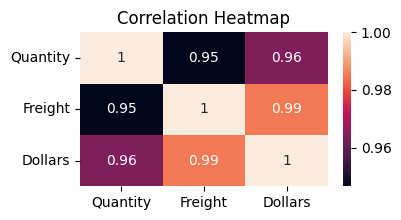

/var/folders/7m/517nrvnd6nbgb3qnkgf7rp680000gn/T/ipykernel_46249/2568316429.py:21: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Quantity','Dollars')


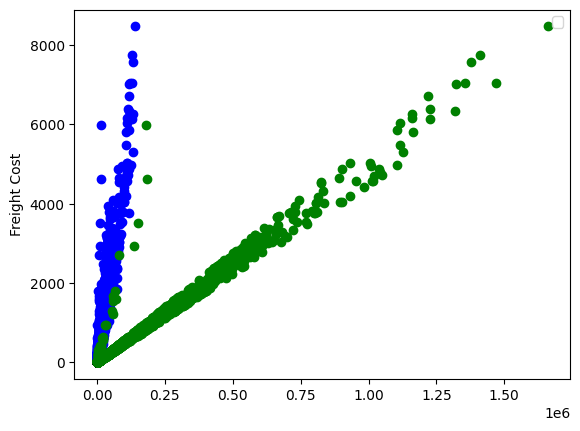

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
plt.figure(figsize=(4,2))
corr = vendor_df[['Quantity','Freight','Dollars']].corr()

# Heatmap
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='blue')

# Dollars vs Freight

plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='green')

plt.ylabel('Freight Cost')
plt.legend('Quantity','Dollars')
plt.show()

In [7]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [8]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [9]:

high_quantity

5100.5

In [10]:
low_quantity

83.0

In [11]:
vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean()


0.09489854253138316

In [12]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

0.049077654690759046

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Features and target
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

# Fit models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("-"*30)

# Evaluate all models
print("Linear Regression")
evaluate_model(lr, X_test, y_test)

print("Decision Tree")
evaluate_model(dt, X_test, y_test)

print("Random Forest")
evaluate_model(rf, X_test, y_test)

Linear Regression
MAE: 24.10597707287569
MSE: 15555.318371054229
R2 Score: 0.9698787714456558
------------------------------
Decision Tree
MAE: 32.647608330828575
MSE: 26809.993485855262
R2 Score: 0.9480852836268119
------------------------------
Random Forest
MAE: 28.273276444107484
MSE: 20224.788048367034
R2 Score: 0.9608368373609351
------------------------------


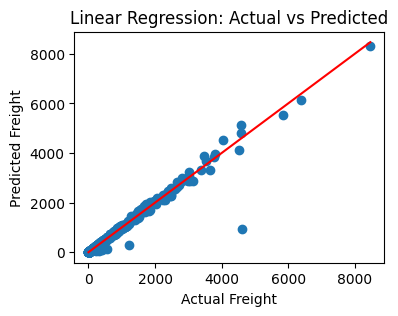

In [23]:
import matplotlib.pyplot as plt

y_pred_lr = lr.predict(X_test)

plt.figure(figsize=(4,3))

plt.scatter(y_test, y_pred_lr)

# Ideal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Freight")
plt.ylabel("Predicted Freight")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [24]:
input_data={
    "Dollars":[18500,9000],
}
df=pd.DataFrame(input_data)


In [25]:
lr.predict(df)

array([97.78868161, 50.14455838])